# Uber Customer Segmentation: Christmas Day 2023

New York City is a premier destination during holiday season. As festivities span from Fifth Avenue to Central Park, rideshare platforms become essential for traveling within and across boroughs. This report utilizes K-means clustering to segment Uber's customer during the 2023 Christmas period.

## Import Library

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

rand_state = 1012026
import warnings
warnings.filterwarnings('ignore')

## Data Pre-preprocessing

In [26]:
data = pd.read_csv("2023_High_Volume_FHV_Trip_Data_20251226.csv")
df = pd.DataFrame(data)
df

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag
0,HV0003,B03404,B03404,12/25/2023 01:00:00 AM,12/25/2023 12:50:56 AM,12/25/2023 12:56:22 AM,12/25/2023 01:34:28 AM,246,23,20.26,...,6.58,2.75,0.0,0.00,54.37,N,N,N,N,False
1,HV0003,B03404,B03404,12/25/2023 01:00:00 AM,12/25/2023 12:56:21 AM,12/25/2023 12:57:28 AM,12/25/2023 01:33:32 AM,107,132,21.77,...,6.63,2.75,2.5,0.00,54.19,N,N,N,N,False
2,HV0003,B03404,B03404,12/25/2023 01:00:00 AM,12/25/2023 12:58:42 AM,12/25/2023 12:59:46 AM,12/25/2023 01:29:45 AM,36,22,11.55,...,3.63,0.00,0.0,0.00,38.36,N,N,N,N,False
3,HV0003,B03404,B03404,12/25/2023 01:00:00 AM,12/25/2023 12:50:39 AM,12/25/2023 12:59:05 AM,12/25/2023 01:34:18 AM,61,132,10.26,...,4.53,0.00,2.5,0.00,36.42,N,N,N,N,False
4,HV0003,B03404,B03404,12/25/2023 01:00:00 AM,12/25/2023 12:41:24 AM,12/25/2023 12:46:43 AM,12/25/2023 01:29:28 AM,198,265,20.34,...,0.00,0.00,0.0,0.00,57.97,N,N,N,N,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288432,HV0003,B03404,B03404,12/25/2023 11:32:56 PM,12/26/2023 12:05:08 AM,12/26/2023 12:05:09 AM,12/26/2023 12:09:49 AM,174,18,0.87,...,0.87,0.00,0.0,0.00,5.39,N,N,N,N,False
288433,HV0003,B03404,B03404,12/25/2023 11:41:47 PM,12/25/2023 11:58:36 PM,12/26/2023 12:00:38 AM,12/26/2023 12:16:46 AM,60,18,4.36,...,1.79,0.00,0.0,0.00,14.96,N,N,N,N,False
288434,HV0003,B03404,B03404,12/25/2023 11:44:48 PM,12/26/2023 12:08:03 AM,12/26/2023 12:08:03 AM,12/26/2023 12:47:02 AM,132,50,27.86,...,5.66,2.75,2.5,11.09,58.59,N,N,N,N,False
288435,HV0003,B03404,B03404,12/25/2023 11:42:52 PM,12/26/2023 12:00:29 AM,12/26/2023 12:01:15 AM,12/26/2023 12:40:31 AM,222,79,21.35,...,4.57,2.75,0.0,0.00,60.33,N,N,N,N,True


In [27]:
# no missing values
print(df.isna().sum())

hvfhs_license_num       0
dispatching_base_num    0
originating_base_num    0
request_datetime        0
on_scene_datetime       0
pickup_datetime         0
dropoff_datetime        0
PULocationID            0
DOLocationID            0
trip_miles              0
trip_time               0
base_passenger_fare     0
tolls                   0
bcf                     0
sales_tax               0
congestion_surcharge    0
airport_fee             0
tips                    0
driver_pay              0
shared_request_flag     0
shared_match_flag       0
access_a_ride_flag      0
wav_request_flag        0
wav_match_flag          0
dtype: int64


In [28]:
# no duplicates
df.duplicated().sum()

np.int64(0)

In [29]:
# drop ID
df = df.drop(columns=["hvfhs_license_num", "dispatching_base_num", "originating_base_num"])

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288437 entries, 0 to 288436
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   request_datetime      288437 non-null  object 
 1   on_scene_datetime     288437 non-null  object 
 2   pickup_datetime       288437 non-null  object 
 3   dropoff_datetime      288437 non-null  object 
 4   PULocationID          288437 non-null  int64  
 5   DOLocationID          288437 non-null  int64  
 6   trip_miles            288437 non-null  float64
 7   trip_time             288437 non-null  object 
 8   base_passenger_fare   288437 non-null  object 
 9   tolls                 288437 non-null  float64
 10  bcf                   288437 non-null  float64
 11  sales_tax             288437 non-null  float64
 12  congestion_surcharge  288437 non-null  float64
 13  airport_fee           288437 non-null  float64
 14  tips                  288437 non-null  float64
 15  

In [31]:
# feature engineering : time of the day
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

df['pickup_hour'] = df['pickup_datetime'].dt.hour

def time_of_day(h):
    if 6 <= h <= 10 :
        return 'morning_peak'
    elif 11 <= h <= 15 :
        return 'midday'
    elif 16 <= h <= 20:
        return 'evening_peak'
    else:
        return 'night'
    
df['time_of_day'] = df['pickup_hour'].apply(time_of_day)
df['time_of_day'] = df['time_of_day'].astype('category')
df['time_of_day']

0         night
1         night
2         night
3         night
4         night
          ...  
288432    night
288433    night
288434    night
288435    night
288436    night
Name: time_of_day, Length: 288437, dtype: category
Categories (4, object): ['evening_peak', 'midday', 'morning_peak', 'night']

In [32]:
# fail to convert 'base_passenger_fare' into float due to comma
mask_valid = df['base_passenger_fare'].astype(str).str.match(r'^-?\d*\.?\d+$')
invalid_rows = df.loc[~mask_valid]
invalid_rows

,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,tolls,...,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,pickup_hour,time_of_day
254851,12/25/2023 08:51:43 PM,12/25/2023 09:01:38 PM,2023-12-25 21:02:34,2023-12-26 03:49:45,247,265,129.14,"24,431","1,218.1",40.82,...,0.0,0.0,866.69,N,N,N,N,False,21,night


In [33]:
# convert successfully
df['base_passenger_fare'] = df['base_passenger_fare'].astype(str).str.replace(',', '').astype(float)
print(df['base_passenger_fare'].dtype)

float64


In [34]:
# fail to convert 'trip_time' into integer due to commas
mask_valid = df['trip_time'].astype(str).str.match(r'^\D+$')
invalid_rows = df.loc[~mask_valid]
invalid_rows

,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,tolls,...,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,pickup_hour,time_of_day
0,12/25/2023 01:00:00 AM,12/25/2023 12:50:56 AM,2023-12-25 00:56:22,2023-12-25 01:34:28,246,23,20.26,"2,286",53.28,20.82,...,0.0,0.00,54.37,N,N,N,N,False,0,night
1,12/25/2023 01:00:00 AM,12/25/2023 12:56:21 AM,2023-12-25 00:57:28,2023-12-25 01:33:32,107,132,21.77,"2,164",72.26,0.00,...,2.5,0.00,54.19,N,N,N,N,False,0,night
2,12/25/2023 01:00:00 AM,12/25/2023 12:58:42 AM,2023-12-25 00:59:46,2023-12-25 01:29:45,36,22,11.55,"1,799",40.92,0.00,...,0.0,0.00,38.36,N,N,N,N,False,0,night
3,12/25/2023 01:00:00 AM,12/25/2023 12:50:39 AM,2023-12-25 00:59:05,2023-12-25 01:34:18,61,132,10.26,"2,113",48.56,0.00,...,2.5,0.00,36.42,N,N,N,N,False,0,night
4,12/25/2023 01:00:00 AM,12/25/2023 12:41:24 AM,2023-12-25 00:46:43,2023-12-25 01:29:28,198,265,20.34,"2,565",57.83,20.00,...,0.0,0.00,57.97,N,N,N,N,False,0,night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288432,12/25/2023 11:32:56 PM,12/26/2023 12:05:08 AM,2023-12-26 00:05:09,2023-12-26 00:09:49,174,18,0.87,280,9.77,0.00,...,0.0,0.00,5.39,N,N,N,N,False,0,night
288433,12/25/2023 11:41:47 PM,12/25/2023 11:58:36 PM,2023-12-26 00:00:38,2023-12-26 00:16:46,60,18,4.36,968,20.16,0.00,...,0.0,0.00,14.96,N,N,N,N,False,0,night
288434,12/25/2023 11:44:48 PM,12/26/2023 12:08:03 AM,2023-12-26 00:08:03,2023-12-26 00:47:02,132,50,27.86,"2,339",54.36,6.94,...,2.5,11.09,58.59,N,N,N,N,False,0,night
288435,12/25/2023 11:42:52 PM,12/26/2023 12:00:29 AM,2023-12-26 00:01:15,2023-12-26 00:40:31,222,79,21.35,"2,356",51.46,0.00,...,0.0,0.00,60.33,N,N,N,N,True,0,night


In [35]:
# convert successfully
df['trip_time'] = df['trip_time'].astype(str).str.replace(',', '').astype(int)
print(df['trip_time'].dtype)

# recheck trip_time = dropoff_datetime - pickup_datetime
recheck = (df['dropoff_datetime'] - df['pickup_datetime']).dt.seconds
print(recheck)
print(df['trip_time'])

int64
0         2286
1         2164
2         1799
3         2113
4         2565
          ... 
288432     280
288433     968
288434    2339
288435    2356
288436     853
Length: 288437, dtype: int32
0         2286
1         2164
2         1799
3         2113
4         2565
          ... 
288432     280
288433     968
288434    2339
288435    2356
288436     853
Name: trip_time, Length: 288437, dtype: int64


In [36]:
# feature engineering : trip_hour, speed_mph, 
df['trip_hour'] = df['trip_time'] / 3600
df['speed_mph'] = df['trip_miles'] / df['trip_hour']

In [37]:
# convert into binary data
flag_cols = ['shared_match_flag', 'access_a_ride_flag']
for c in flag_cols:
    df[c] = df[c].map({'Y' : 1, 'N' : 0})

df['wav_match_flag'] = df['wav_match_flag'].astype(int)

df[['shared_match_flag', 'access_a_ride_flag', 'wav_match_flag']]

,shared_match_flag,access_a_ride_flag,wav_match_flag
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
288432,0,0,0
288433,0,0,0
288434,0,0,0
288435,0,0,1


In [38]:
df['airport_trip'] = (df['airport_fee'] > 0).astype(int)
df['is_congested'] = (df['congestion_surcharge'] > 0).astype(int)

In [39]:
num_cols = ['trip_miles', 'trip_time', 'base_passenger_fare', 'tolls', 'bcf', 'tips', 'speed_mph']
binary_cols = ['shared_match_flag', 'access_a_ride_flag', 'wav_match_flag', 'airport_trip', 'is_congested']
cat_cols = ['time_of_day']
X = df[num_cols+binary_cols+cat_cols]
X

,trip_miles,trip_time,base_passenger_fare,tolls,bcf,tips,speed_mph,shared_match_flag,access_a_ride_flag,wav_match_flag,airport_trip,is_congested,time_of_day
0,20.26,2286,53.28,20.82,2.04,0.00,31.905512,0,0,0,0,1,night
1,21.77,2164,72.26,0.00,2.06,0.00,36.216266,0,0,0,1,1,night
2,11.55,1799,40.92,0.00,1.13,0.00,23.112840,0,0,0,0,0,night
3,10.26,2113,48.56,0.00,1.40,0.00,17.480360,0,0,0,1,0,night
4,20.34,2565,57.83,20.00,2.14,0.00,28.547368,0,0,0,0,0,night
...,...,...,...,...,...,...,...,...,...,...,...,...,...
288432,0.87,280,9.77,0.00,0.27,0.00,11.185714,0,0,0,0,0,night
288433,4.36,968,20.16,0.00,0.55,0.00,16.214876,0,0,0,0,0,night
288434,27.86,2339,54.36,6.94,1.75,11.09,42.879863,0,0,0,1,1,night
288435,21.35,2356,51.46,0.00,1.42,0.00,32.623090,0,0,1,0,1,night


## Exploratory Data Analysis

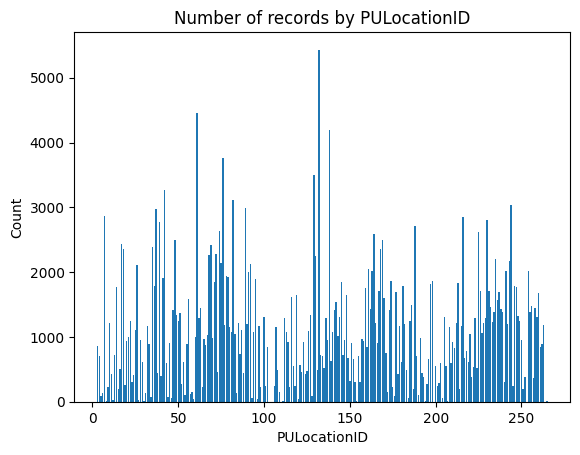

PULocationID
132    5433
61     4460
138    4193
76     3767
129    3506
Name: count, dtype: int64

In [40]:
pu_counts = df['PULocationID'].value_counts().sort_index()

plt.bar(pu_counts.index, pu_counts.values)
plt.xlabel("PULocationID")
plt.ylabel("Count")
plt.title("Number of records by PULocationID")
plt.show()

top5_pu = pu_counts.sort_values(ascending=False)
top5_pu.head()

Pickup volume was highest at JFK Airport, followed by Crown Heights North, LaGuardia Airport, East Flatbush/Remsen Village, and Jackson Heights. These areas represent airport and residential zones where population volume and global flight schedules create high demand for for-hire vehicles.

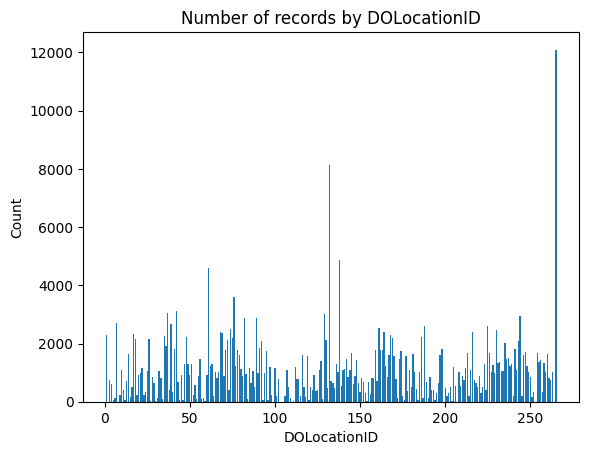

DOLocationID
265    12092
132     8135
138     4875
61      4590
76      3592
Name: count, dtype: int64

In [41]:
do_counts = df['DOLocationID'].value_counts().sort_index()

plt.bar(do_counts.index, do_counts.values)
plt.xlabel("DOLocationID")
plt.ylabel("Count")
plt.title("Number of records by DOLocationID")
plt.show()

top5_do = do_counts.sort_values(ascending= False)
top5_do.head()

Outside NYC represents the primary drop-off location, with JFK Airport, LaGuardia Airport, Crown Heights North, and East New York following as the top intra-city locations.

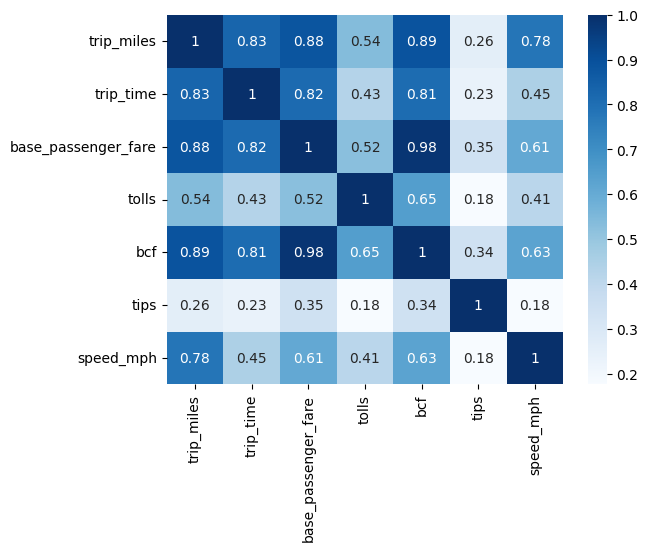

In [42]:
sns.heatmap(df[num_cols].corr(), cmap='Blues', annot=True)
plt.show()

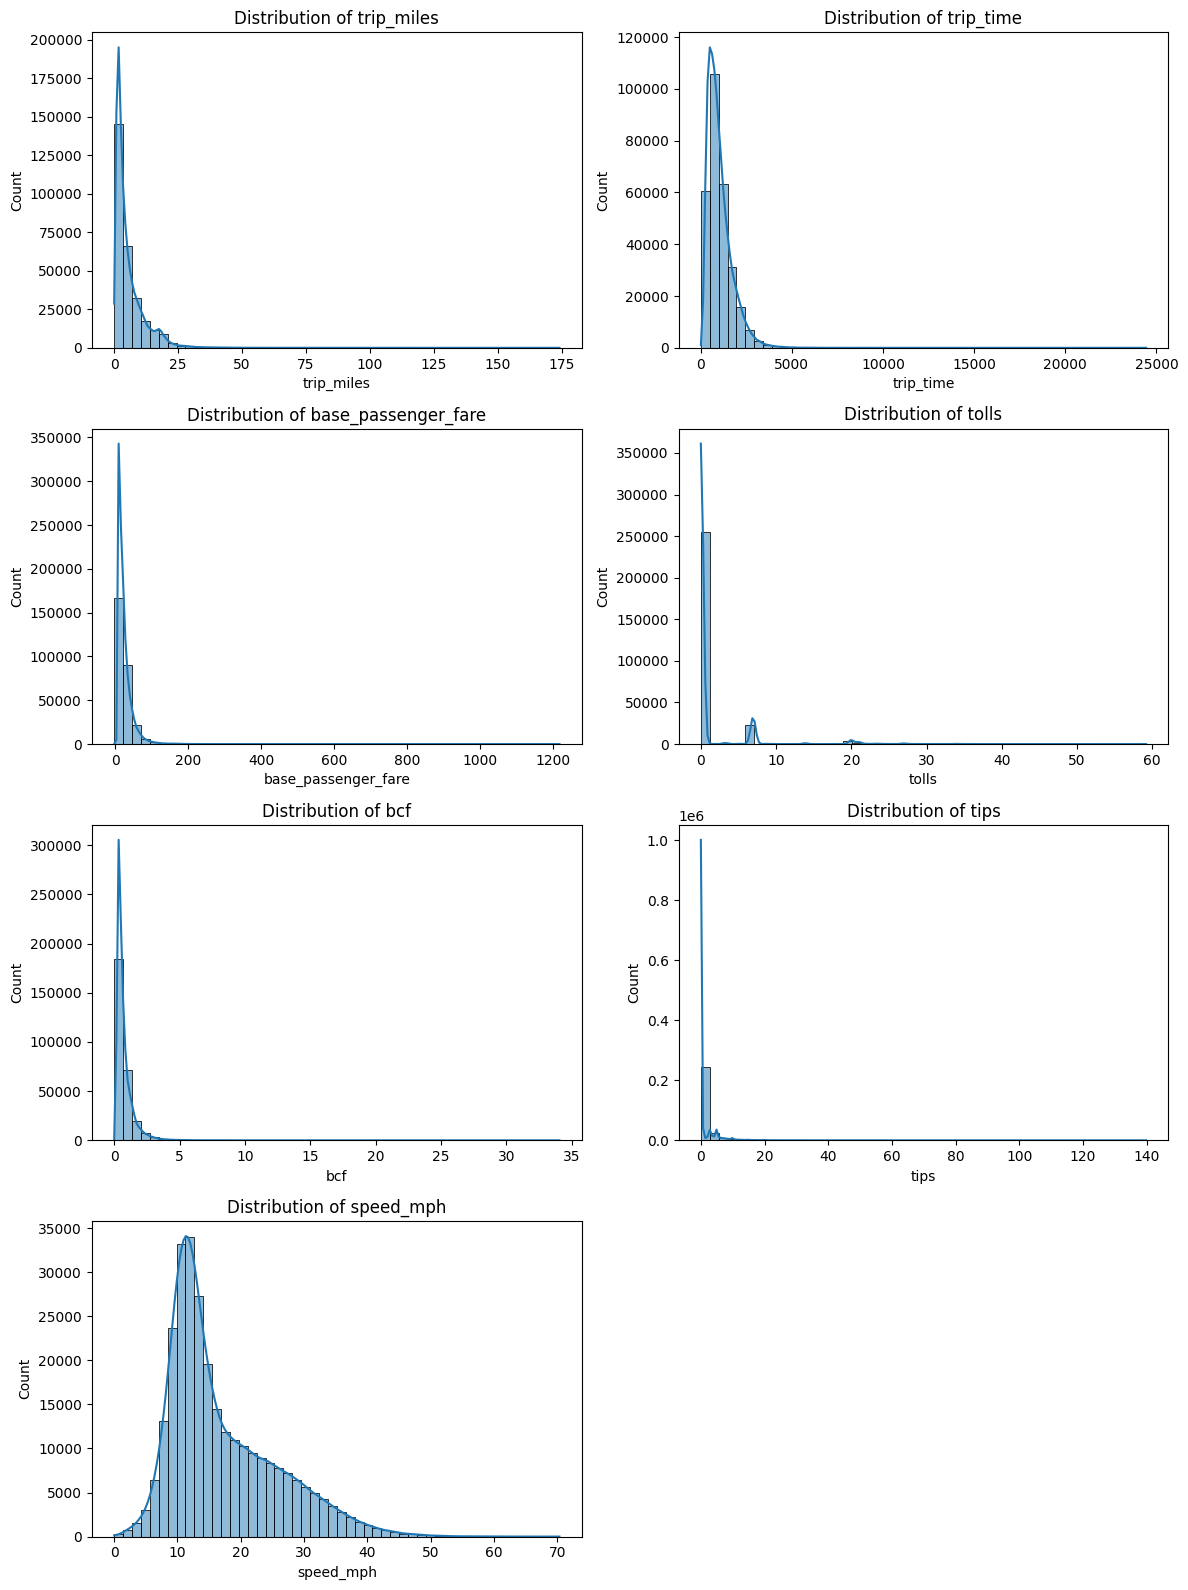

In [43]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(X[col], bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

# hide unused subplot
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- Many trips had no tip at all as the bars are compressed near 0.
- Customers preferred not to use toll way.
- Speed is concentrated around 15 mph, highlighting urban congestion in NYC.

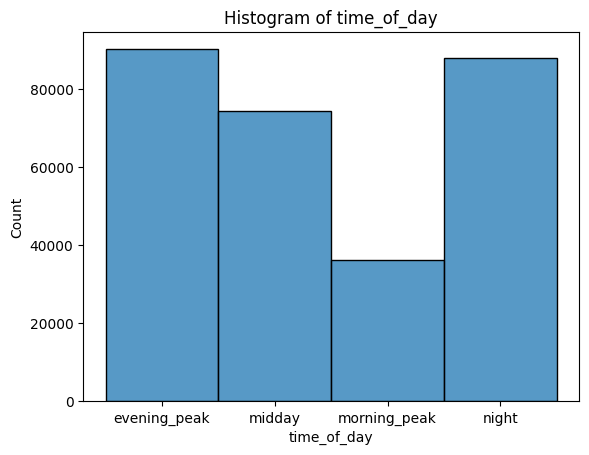

In [44]:
sns.histplot(X['time_of_day'])
plt.title('Histogram of time_of_day')
plt.show()

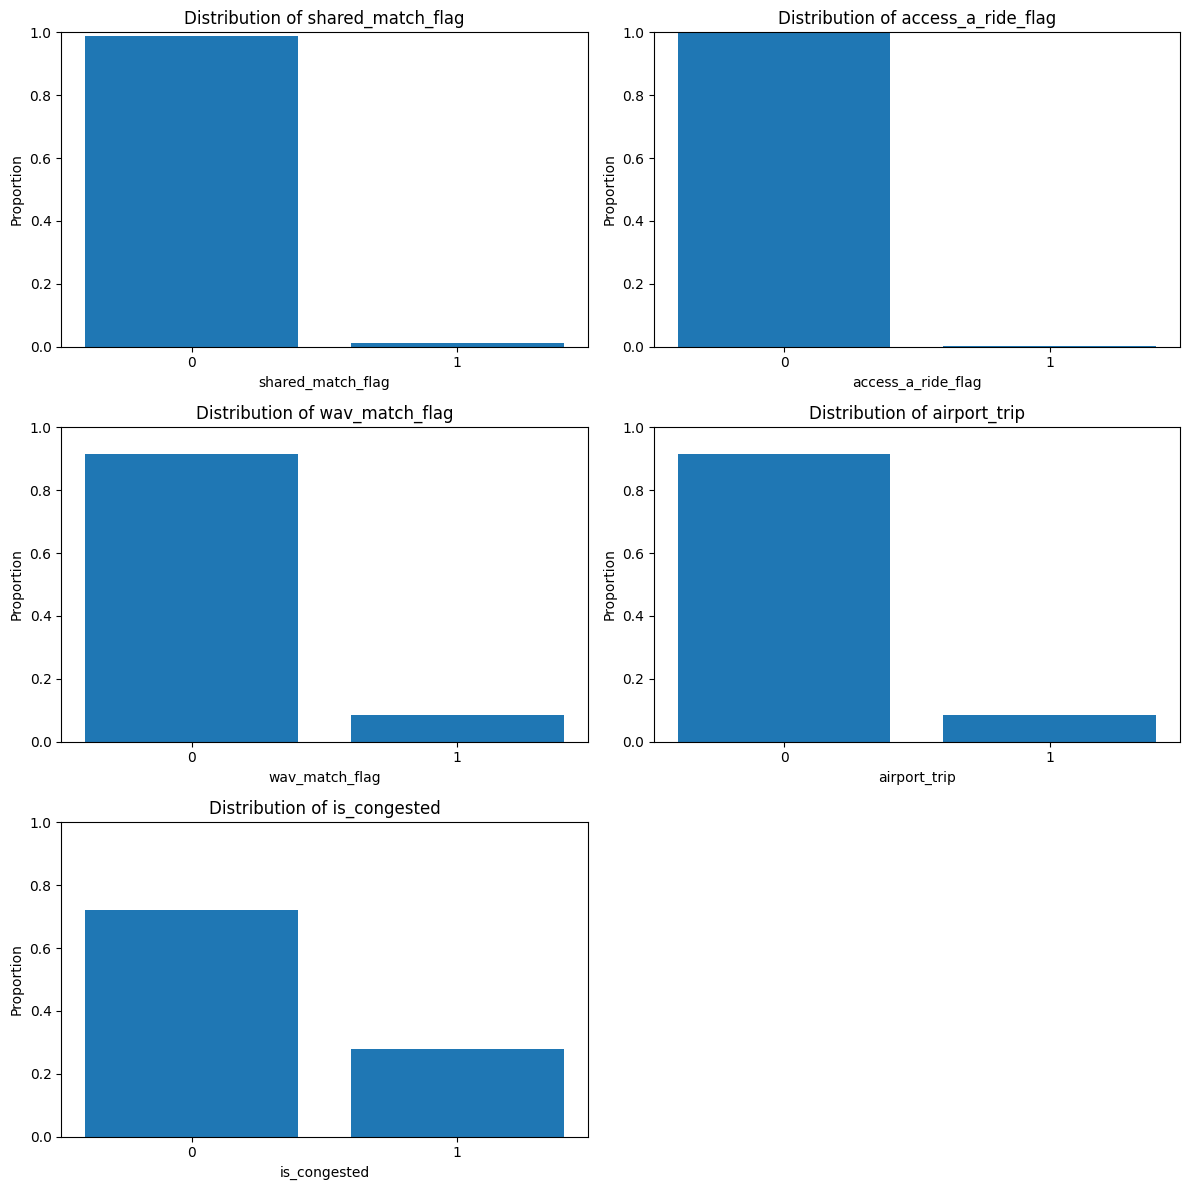

In [45]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    counts = df[col].value_counts(normalize=True).sort_index()

    axes[i].bar(counts.index.astype(str), counts.values)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Proportion")  
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylim(0, 1) 

# hide unused subplot
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [46]:
for col in binary_cols:
    print(df[col].value_counts(normalize=True).sort_index())

shared_match_flag
0    0.988722
1    0.011278
Name: proportion, dtype: float64
access_a_ride_flag
0    0.999421
1    0.000579
Name: proportion, dtype: float64
wav_match_flag
0    0.91525
1    0.08475
Name: proportion, dtype: float64
airport_trip
0    0.916568
1    0.083432
Name: proportion, dtype: float64
is_congested
0    0.721308
1    0.278692
Name: proportion, dtype: float64


- The vast majority of trips were independent of MTA.
- Nearly all trips were of private trips.
- Congestion surcharge wes applied to 27% of all trips.
- Airport-related trips accounted for 8% of all trips.

## K-means Clustering

In [47]:
# using one hot encode for time_of_day field
cat_dummies = pd.get_dummies(df[cat_cols], drop_first=False).astype(int)
cat_dummies


,time_of_day_evening_peak,time_of_day_midday,time_of_day_morning_peak,time_of_day_night
0,0,0,0,1
1,0,0,0,1
2,0,0,0,1
3,0,0,0,1
4,0,0,0,1
...,...,...,...,...
288432,0,0,0,1
288433,0,0,0,1
288434,0,0,0,1
288435,0,0,0,1


In [48]:
# drop unused column
X = X.drop(columns='time_of_day')
X = pd.concat([X, cat_dummies], axis=1)
X

,trip_miles,trip_time,base_passenger_fare,tolls,bcf,tips,speed_mph,shared_match_flag,access_a_ride_flag,wav_match_flag,airport_trip,is_congested,time_of_day_evening_peak,time_of_day_midday,time_of_day_morning_peak,time_of_day_night
0,20.26,2286,53.28,20.82,2.04,0.00,31.905512,0,0,0,0,1,0,0,0,1
1,21.77,2164,72.26,0.00,2.06,0.00,36.216266,0,0,0,1,1,0,0,0,1
2,11.55,1799,40.92,0.00,1.13,0.00,23.112840,0,0,0,0,0,0,0,0,1
3,10.26,2113,48.56,0.00,1.40,0.00,17.480360,0,0,0,1,0,0,0,0,1
4,20.34,2565,57.83,20.00,2.14,0.00,28.547368,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288432,0.87,280,9.77,0.00,0.27,0.00,11.185714,0,0,0,0,0,0,0,0,1
288433,4.36,968,20.16,0.00,0.55,0.00,16.214876,0,0,0,0,0,0,0,0,1
288434,27.86,2339,54.36,6.94,1.75,11.09,42.879863,0,0,0,1,1,0,0,0,1
288435,21.35,2356,51.46,0.00,1.42,0.00,32.623090,0,0,1,0,1,0,0,0,1


In [49]:
# Applying MinMaxScaler to normalize features, ensuring that variables with large ranges do not disproportionately influence the distance
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

all_cols = num_cols + binary_cols + list(cat_dummies.columns)

# convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=all_cols)
display(X_scaled)

# ensure min and max from all columns
print(f'Data min:max {X_scaled.min().min(),X_scaled.max().max()}')

,trip_miles,trip_time,base_passenger_fare,tolls,bcf,tips,speed_mph,shared_match_flag,access_a_ride_flag,wav_match_flag,airport_trip,is_congested,time_of_day_evening_peak,time_of_day_midday,time_of_day_morning_peak,time_of_day_night
0,0.116450,0.092901,0.045894,0.351749,0.059877,0.000000,0.453750,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.125129,0.087904,0.061441,0.000000,0.060464,0.000000,0.515056,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
2,0.066387,0.072953,0.035770,0.000000,0.033167,0.000000,0.328703,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.058972,0.085815,0.042028,0.000000,0.041092,0.000000,0.248600,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.116910,0.104330,0.049621,0.337895,0.062812,0.000000,0.405991,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288432,0.005001,0.010732,0.010255,0.000000,0.007925,0.000000,0.159079,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
288433,0.025060,0.038914,0.018766,0.000000,0.016143,0.000000,0.230603,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
288434,0.160133,0.095072,0.046779,0.117250,0.051365,0.079288,0.609823,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
288435,0.122715,0.095769,0.044403,0.000000,0.041679,0.000000,0.463955,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


Data min:max (np.float64(0.0), np.float64(1.0))


### Elbow method

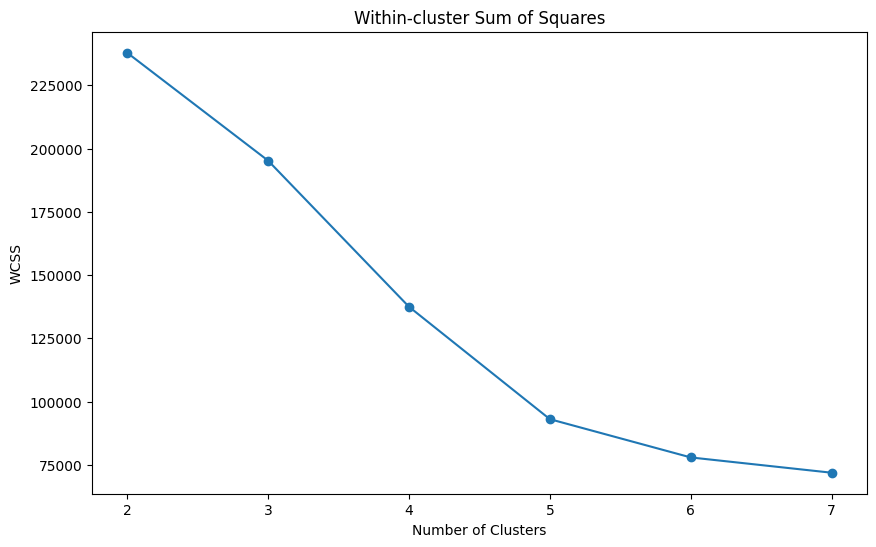

In [50]:
wcss = []
for k in range(2,8):
    kmeans = KMeans(n_clusters= k , random_state= rand_state)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(range(2,8), wcss, marker='o')
plt.title('Within-cluster Sum of Squares')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

n_clusters = 3, 4, 5 should be the candidates for choosing the best K.

### Silhouette Analysis

We evaluated silhouette on the sample only because distance calculations are heavy.

In [51]:
sample_df = X_scaled.sample(frac = 0.1, random_state = rand_state)

For n_clusters = 3 The average silhouette_score is : 0.4711530102782984


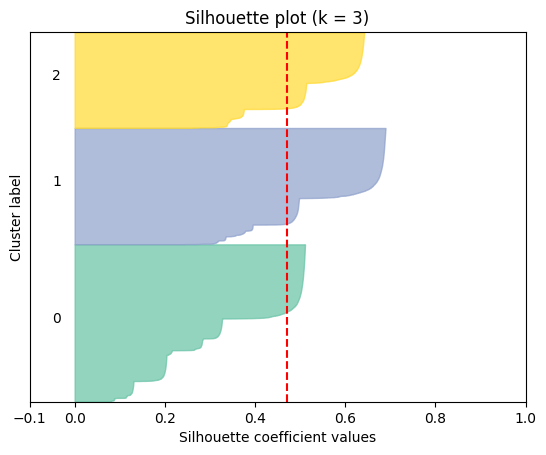

For n_clusters = 4 The average silhouette_score is : 0.5717262485709865


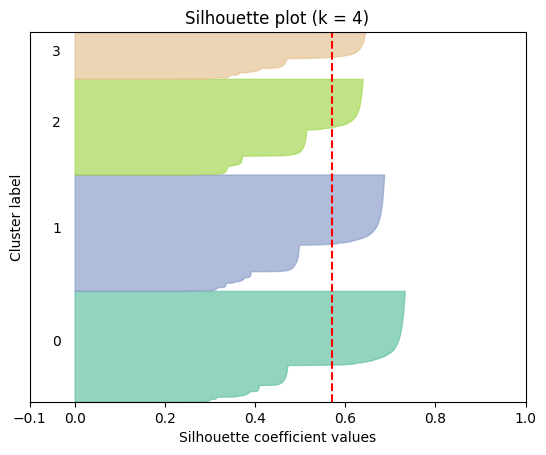

For n_clusters = 5 The average silhouette_score is : 0.5670537875911513


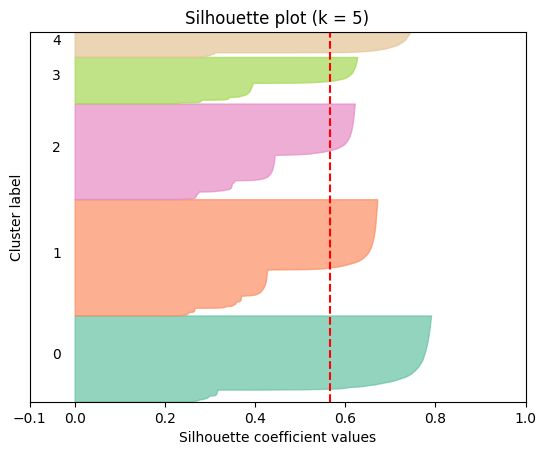

In [52]:
k_range = [3, 4, 5]

for n_clusters in k_range:
    plt.figure()

    plt.xlim([-0.1, 1])
    plt.ylim([0, len(sample_df) + (n_clusters + 1) * 10])


    clusterer = KMeans(n_clusters=n_clusters, random_state=rand_state)
    cluster_labels = clusterer.fit_predict(sample_df)

    silhouette_avg = silhouette_score(sample_df, cluster_labels)
    print("For n_clusters =",n_clusters,"The average silhouette_score is :",silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(sample_df, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.Set2(float(i) / n_clusters)
        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    plt.title(f"Silhouette plot (k = {n_clusters})")
    plt.xlabel("Silhouette coefficient values")
    plt.ylabel("Cluster label")

    plt.axvline(x=silhouette_avg, linestyle="--", color='red')

    plt.yticks([])
    plt.xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.show()

The silhouette plots indicates that k = 4 yields the highest average silhouette coefficient. The silhouette plots also show that all observations have positive coefficients, indicating well-defined clusters.

### Cluster Analysis

In [75]:
model = KMeans(n_clusters= 4, random_state=rand_state)
model.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",1012026
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [76]:
X_scaled['cluster'] = model.labels_
X['cluster'] = model.labels_

In [77]:
display(X)
display(X_scaled)

,trip_miles,trip_time,base_passenger_fare,tolls,bcf,tips,speed_mph,shared_match_flag,access_a_ride_flag,wav_match_flag,airport_trip,is_congested,time_of_day_evening_peak,time_of_day_midday,time_of_day_morning_peak,time_of_day_night,cluster
0,20.26,2286,53.28,20.82,2.04,0.00,31.905512,0,0,0,0,1,0,0,0,1,0
1,21.77,2164,72.26,0.00,2.06,0.00,36.216266,0,0,0,1,1,0,0,0,1,0
2,11.55,1799,40.92,0.00,1.13,0.00,23.112840,0,0,0,0,0,0,0,0,1,0
3,10.26,2113,48.56,0.00,1.40,0.00,17.480360,0,0,0,1,0,0,0,0,1,0
4,20.34,2565,57.83,20.00,2.14,0.00,28.547368,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288432,0.87,280,9.77,0.00,0.27,0.00,11.185714,0,0,0,0,0,0,0,0,1,0
288433,4.36,968,20.16,0.00,0.55,0.00,16.214876,0,0,0,0,0,0,0,0,1,0
288434,27.86,2339,54.36,6.94,1.75,11.09,42.879863,0,0,0,1,1,0,0,0,1,0
288435,21.35,2356,51.46,0.00,1.42,0.00,32.623090,0,0,1,0,1,0,0,0,1,0


,trip_miles,trip_time,base_passenger_fare,tolls,bcf,tips,speed_mph,shared_match_flag,access_a_ride_flag,wav_match_flag,airport_trip,is_congested,time_of_day_evening_peak,time_of_day_midday,time_of_day_morning_peak,time_of_day_night,cluster
0,0.116450,0.092901,0.045894,0.351749,0.059877,0.000000,0.453750,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0
1,0.125129,0.087904,0.061441,0.000000,0.060464,0.000000,0.515056,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0
2,0.066387,0.072953,0.035770,0.000000,0.033167,0.000000,0.328703,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3,0.058972,0.085815,0.042028,0.000000,0.041092,0.000000,0.248600,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
4,0.116910,0.104330,0.049621,0.337895,0.062812,0.000000,0.405991,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288432,0.005001,0.010732,0.010255,0.000000,0.007925,0.000000,0.159079,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
288433,0.025060,0.038914,0.018766,0.000000,0.016143,0.000000,0.230603,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
288434,0.160133,0.095072,0.046779,0.117250,0.051365,0.079288,0.609823,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0
288435,0.122715,0.095769,0.044403,0.000000,0.041679,0.000000,0.463955,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0


cluster
0    87894
1    74228
2    90051
3    36264
Name: count, dtype: int64


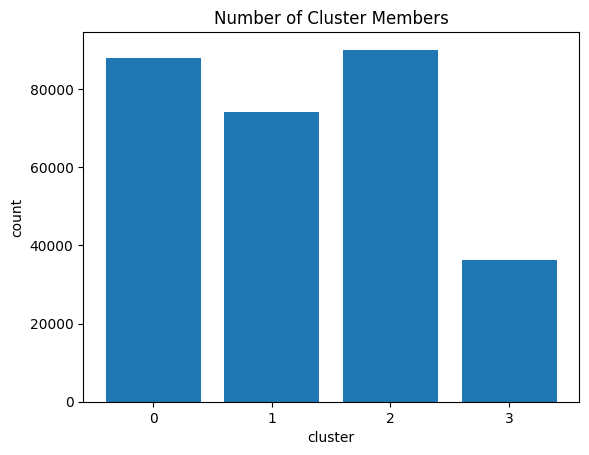

In [78]:
cluster_count = X.value_counts('cluster').sort_index()
print(cluster_count)

plt.bar(cluster_count.index.astype(str), cluster_count.values)
plt.xlabel('cluster')
plt.ylabel('count')
plt.title('Number of Cluster Members')
plt.show()


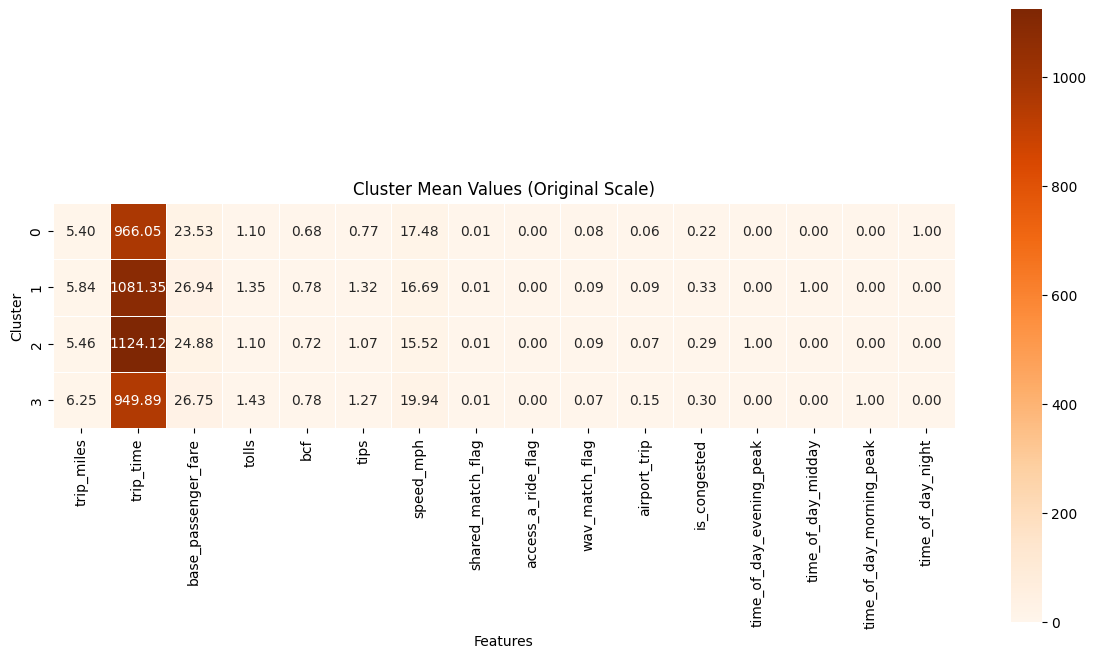

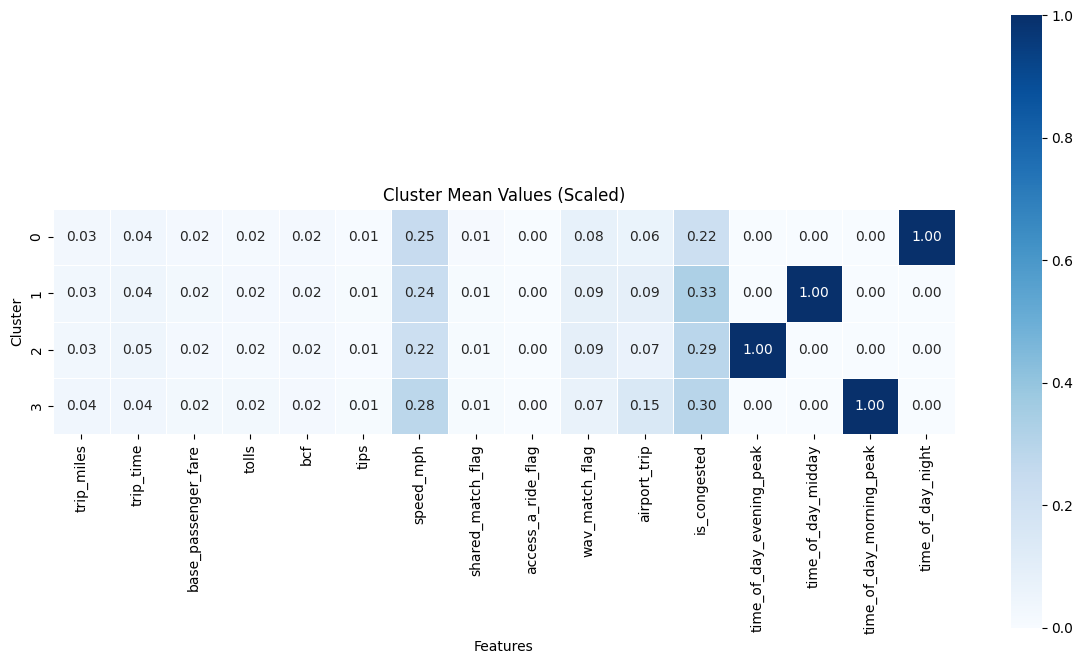

In [80]:
# Heatmap 1: original scale 
plt.figure(figsize=(12, 8))
sns.heatmap(
    X.groupby('cluster').mean(),
    cmap='Oranges',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8},
    square=True
)
plt.title('Cluster Mean Values (Original Scale)')
plt.xlabel('Features')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

# Heatmap 2: scaled data
plt.figure(figsize=(12, 8))
sns.heatmap(
    X_scaled.groupby('cluster').mean(),
    cmap='Blues',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8},
    square=True
)
plt.title('Cluster Mean Values (Scaled)')
plt.xlabel('Features')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()


Uber customers can be segmented into four distinct clusters based on time-of-day patterns: <br>

1. Cluster 0 – Night commuters (approximately 9:00 PM to 5:00 AM) <br>

2. Cluster 1 – Midday commuters (approximately 11:00 AM to 3:00 PM) <br>
It exhibits the highest average base passenger fare at approximately USD 26.94.

3. Cluster 2 – Evening commuters (approximately 4:00 PM to 8:00 PM) <br>
Trips in this cluster are concentrated during evening peak hours of NYC. This is the largest segment, representing 90,051 trips. Moreover, trips exhibit the highest average duration, with average times of 19 minutes.

4. Cluster 3 – Morning commuters (approximately 6:00 AM to 10:00 AM) <br>
This is the smallest segment, accounting for 36,264 trips. This cluster exhibits the highest ratio of airport trips, at roughly 15 percent.


The four clusters share the following common characteristics:
1. The average trip distance is approximately 6 miles.
2. A congestion surcharge is applied in about 30 percent of trips.
3. Almost every trips are individual rides.